# Projekt: Eco-Designer 🦊🐭
## Teil 1: Das Basismodell (Die digitale Kopie des Brettspiels)

Willkommen im Software-Testlabor! Letzte Woche habt ihr das Räuber-Beute-Spiel manuell mit Karten auf dem Tisch durchgespielt. Ihr habt gemerkt: Die Natur nach festen Regeln auszuwürfeln dauert lange – und das System stürzt ständig ab, sodass man es künstlich neu starten muss.

Heute schalten wir um in den **God-Mode**. Als Informatiker lassen wir den Computer die Arbeit machen. Wir übersetzen eure analogen Spielregeln in Python-Code.

### 📑 Refresher: Die Spielregeln aus Woche 1
* **Startwerte:** 3 Mäuse, 1 Fuchs.
* **Die Limits:** Maximal 234 Mäuse und 36 Füchse (Kapazitätsgrenze der Karten).
* **Mäuse-Vermehrung:** Überlebende Mäuse verdoppeln sich am Rundenende.
* **Fuchs-Sterben:** Weniger als 3 Mäuse gefressen $\rightarrow$ Fuchs stirbt.
* **Fuchs-Nachwuchs:** 4–5 Mäuse gefressen $\rightarrow$ +1 Fuchs. Ab 6 Mäusen $\rightarrow$ +2 Füchse.
* **Zuwanderung:** Wenn alle Füchse sterben, wandert nächste Runde automatisch 1 neuer Fuchs ein.
* **Totaler Crash:** Wenn alle Mäuse sterben, Reset auf Startwerte (3 Mäuse, 1 Fuchs).

In [11]:
import random
import matplotlib.pyplot as plt

# 1. Startwerte exakt gemäss Arbeitsblatt
maeuse = 3
fuechse = 1
runden = 200

# Listen für die Grafik-Historie
historie_maeuse = [maeuse]
historie_fuechse = [fuechse]

# 2. Die Simulations-Schleife
for runde in range(1, runden + 1):

    # --- SCHRITT 1: REVIERKONKURRENZ & ABWANDERUNG  ---
    # Ein A3-Blatt bietet Platz für ca. 32 Fuchskarten.
    # Die Füchse werden nacheinander geworfen. Landet ein Fuchs auf einem anderen, wandert er ab.
    aktive_jagd_fuechse = 0
    for f in range(fuechse):
        ueberlappungs_chance = aktive_jagd_fuechse / 32.0
        if random.random() >= ueberlappungs_chance:
            # Fuchs findet freien Platz auf dem Plan und darf jagen
            aktive_jagd_fuechse += 1
        # Falls er überlappt, wandert er ab und jagt in dieser Runde NICHT mit.

    # --- SCHRITT 2: DIE REALE JAGD ---
    insgesamt_gefressen = 0
    fuechse_naechste_runde = 0

    # Wie dicht sitzen die Mäuse auf dem Feld? Max. 234 Karten haben Platz.
    maus_dichte = maeuse / 234.0
    if maus_dichte > 1.0:
        maus_dichte = 1.0

    # Nur die Füchse, die Platz gefunden haben, gehen jetzt auf die Jagd
    for f in range(aktive_jagd_fuechse):
        # Physik-Korrektur: Bei maximaler Dichte trifft ein Fuchs garantiert (min. 4, max. 8)
        min_fang = int(4 * maus_dichte)
        max_fang = int(8 * maus_dichte)
        fang = random.randint(min_fang, max_fang)

        # Logik-Schutz: Man kann nicht mehr Mäuse fressen als da sind
        if insgesamt_gefressen + fang > maeuse:
            fang = maeuse - insgesamt_gefressen

        insgesamt_gefressen += fang

        # Fuchs-Biologie: Einzelabrechnung pro Karte (Regel 17, 18, 19)
        if fang < 3:
            pass                        # Fuchs verhungert und stirbt
        elif fang == 3:
            fuechse_naechste_runde += 1 # Fuchs überlebt knapp (0 Junge)
        elif 4 <= fang <= 5:
            fuechse_naechste_runde += 2 # Fuchs überlebt + 1 Junges
        elif fang >= 6:
            fuechse_naechste_runde += 3 # Fuchs überlebt + 2 Junge

    # --- SCHRITT 3: BIOLOGIE MAUS (Regel 16 & 21) ---
    ueberlebende_maeuse = maeuse - insgesamt_gefressen
    maeuse = ueberlebende_maeuse * 2    # Überlebende Mäuse verdoppeln sich

    # Absolute Kartenlimits einhalten (Kapazitätsgrenze des Materials)
    if maeuse > 234: maeuse = 234
    if fuechse_naechste_runde > 36: fuechse_naechste_runde = 36

    fuechse = fuechse_naechste_runde

    # --- SCHRITT 4: SPEZIALREGELN (ZUWANDERUNG & RESET) ---
    # Regel 8: Unser Einwanderungs-Patch, falls alle Füchse verhungert sind
    if fuechse <= 0 and maeuse > 0:
        fuechse = 1

    # Regel 22: Totaler Crash (Mäuse sterben aus -> Reset auf Startaufstellung)
    if maeuse <= 0:
        maeuse = 3
        fuechse = 1

    # Daten für die Grafik speichern
    historie_maeuse.append(maeuse)
    historie_fuechse.append(fuechse)

print(f"⚙️ Basis-Simulation über {runden} Runden erfolgreich berechnet.")

⚙️ Basis-Simulation über 200 Runden erfolgreich berechnet.


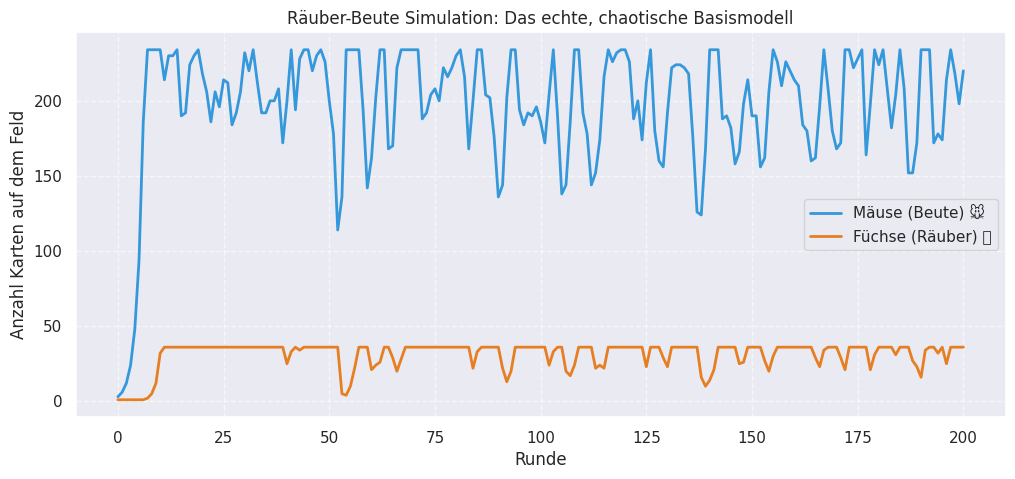

In [12]:
plt.figure(figsize=(12, 5))
plt.plot(historie_maeuse, label='Mäuse (Beute) 🐭', color='#3498db', linewidth=2)
plt.plot(historie_fuechse, label='Füchse (Räuber) 🦊', color='#e67e22', linewidth=2)
plt.title('Räuber-Beute Simulation: Das echte, chaotische Basismodell')
plt.xlabel('Runde')
plt.ylabel('Anzahl Karten auf dem Feld')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

---
## Teil 2: Die Lotka-Volterra Challenge 🏆

Schaut euch das Diagramm oben an: Das Basismodell verhält sich absolut nicht wie die echte Natur. Es schlägt wilde Zacken, explodiert unkontrolliert und stürzt ständig komplett ab.

In der Biologie gibt es drei berühmte Grundregeln für solche Systeme – die **Lotka-Volterra-Regeln**. Das wichtigste Merkmal ist eine **periodische, zeitversetzte Schwingung**:
Die Kurve der Räuber (Füchse) folgt der Kurve der Beute (Mäuse) immer mit einer leichten Verzögerung. Wenn viele Mäuse da sind, wächst die Fuchs-Population. Gibt es zu viele Füchse, bricht der Mäuse-Bestand ein. Dadurch verhungern die Füchse wieder, woraufhin sich die Mäuse erholen können – der Zyklus beginnt von vorn.

**Euer Missions-Auftrag:** Der Code von oben wurde unten (Zelle 5) nochmals hinkopiert. Verändert die mathematischen Mechanismen in der Schleife so, dass ihr es schafft, über die 200 Runden eine **stabile, sich sauber wiederholende Lotka-Volterra-Schwingung** auf dem Bildschirm zu erzeugen!

Das System darf dabei **nie mehr auf die künstliche Reset-Regel** (Zurücksetzen auf 3 Mäuse) angewiesen sein. Welches Team zähmt das Chaos und designt das stabilste Lehrbuch-System?

### 🛠️ Euer Werkzeugkasten (Die Hebel im Code):
Ihr dürft die radikalen Regeln des analogen Spiels entschärfen. Dreht an den mathematischen Schrauben:

1. **Den Zufall ausschalten / dämpfen:** Beim analogen Werfen war viel Glück dabei. Um die reine mathematische Schwingung zu finden, solltet ihr das Zufalls-Element deaktivieren. Setzt den `fang` pro Fuchs testweise auf einen festen Wert (z.B. basierend auf der Dichte) oder verkleinert den Spielraum von `random.randint`.
2. **Die Geburtenrate der Mäuse drosseln:** Die stumpfe Verdopplung (`* 2`) lässt die Mäuse-Kurve viel zu explosiv nach oben schiessen. Was passiert, wenn ihr den Nachwuchs-Faktor auf `1.5`, `1.3` oder gar `1.1` senkt?
3. **Das Fuchs-Sterben sanfter gestalten:** Im Basismodell stirbt bei Hunger sofort die Hälfte aller Füchse auf einen Schlag (`int(fuechse * 0.5)`). Das ist biologisch zu radikal und killt das System. Versucht, das Sterben sanfter zu machen, indem ihr z.B. nur 10% oder 20% der Füchse verhungern lasst.

*Viel Erfolg beim Ausprobieren! Nutzt das Trial-and-Error-Prinzip: Code anpassen, Zelle ausführen, Kurve analysieren!*

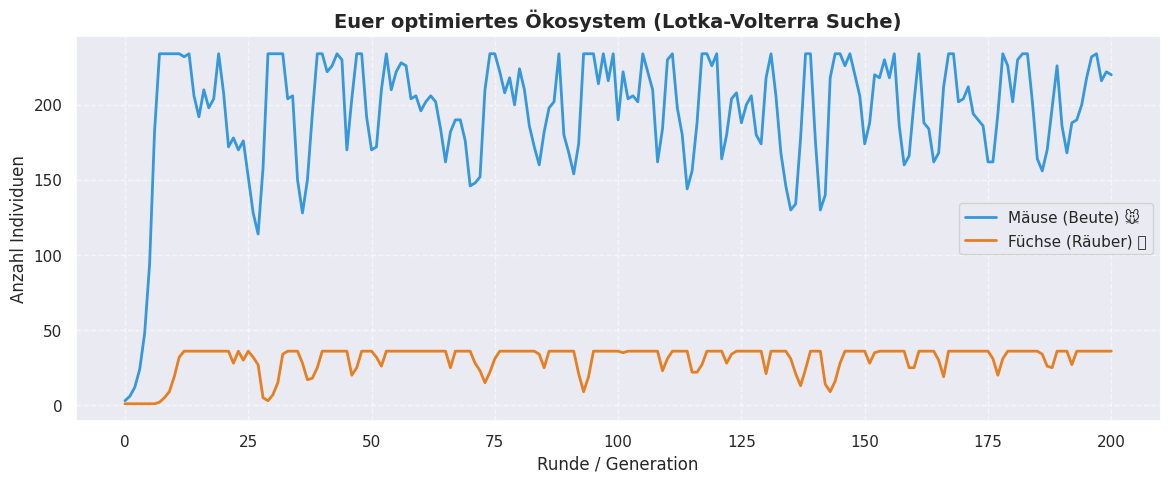

In [13]:
import random
import matplotlib.pyplot as plt

# 1. STARTWERTE (Tipp: Ihr könnt auch hier mit den Startwerten experimentieren!)
maeuse = 3
fuechse = 1
runden = 200

historie_maeuse = [maeuse]
historie_fuechse = [fuechse]

for runde in range(1, runden + 1):

    # =================================================================
    # HEBEL 1: REVIERKONKURRENZ & ZUFALL
    # =================================================================
    aktive_jagd_fuechse = 0
    for f in range(fuechse):
        ueberlappungs_chance = aktive_jagd_fuechse / 32.0
        if random.random() >= ueberlappungs_chance:
            aktive_jagd_fuechse += 1

    insgesamt_gefressen = 0
    fuechse_naechste_runde = 0

    maus_dichte = maeuse / 234.0
    if maus_dichte > 1.0:
        maus_dichte = 1.0

    # Jeder aktive Luchs/Fuchs geht nun auf die Jagd
    for f in range(aktive_jagd_fuechse):

        # --- TODO: SCHRAUBE 1 (Zufall ausschalten / Jagd limitieren) ---
        # Aktuell würfelt das System den Fang komplett zufällig aus (min 4, max 8 bei voller Dichte).
        # TIPP: Ersetzt das random.randint() durch einen festen Wert oder verkleinert die Spanne,
        # damit die Jagd berechenbarer und sanfter für das Ökosystem wird!
        min_fang = int(4 * maus_dichte)
        max_fang = int(8 * maus_dichte)
        fang = random.randint(min_fang, max_fang)

        # -------------------------------------------------------------

        if insgesamt_gefressen + fang > maeuse:
            fang = maeuse - insgesamt_gefressen
        insgesamt_gefressen += fang

        # --- TODO: SCHRAUBE 3 (Fuchs-Biologie sanfter machen) ---
        # Aktuell stirbt bei Hunger sofort die HÄLFTE der Füchse (int * 0.5).
        # TIPP: Macht das Sterben und die Geburt fliessender! Verwendet z.B. statt harten
        # Sprüngen Prozentwerte (z.B. fuechse_naechste_runde += fuechse * 0.9) oder passt die
        # Bedingungen (fang < 3) an.
        if fang < 3:
            pass                        # Fuchs verhungert
        elif fang == 3:
            fuechse_naechste_runde += 1 # Fuchs überlebt knapp
        elif 4 <= fang <= 5:
            fuechse_naechste_runde += 2 # Fuchs überlebt + 1 Junges
        elif fang >= 6:
            fuechse_naechste_runde += 3 # Fuchs überlebt + 2 Junge
        # -------------------------------------------------------------

    # =================================================================
    # HEBEL 2: BIOLOGIE MAUS (Geburtenrate)
    # =================================================================
    ueberlebende_maeuse = maeuse - insgesamt_gefressen

    if ueberlebende_maeuse > 0:
        # --- TODO: SCHRAUBE 2 (Mäuse-Vermehrung drosseln) ---
        # Aktuell verdoppeln sich die Mäuse bedingungslos (* 2). Das ist zu explosiv!
        # TIPP: Ändert den Faktor von 2 auf einen sanfteren Wert (z.B. 1.4 oder 1.2) oder
        # baut eine Bedingung ein, dass sie sich ab 100 Mäusen weniger stark vermehren.
        maeuse = ueberlebende_maeuse * 2
        # -------------------------------------------------------------
    else:
        maeuse = 0

    # -----------------------------------------------------------------
    # ABRECHNUNG & REGLER (Bitte so lassen, damit das Programm stabil bleibt)
    # -----------------------------------------------------------------
    fuechse = fuechse_naechste_runde
    if maeuse > 234: maeuse = 234
    if fuechse > 36: fuechse = 36

    # HINWEIS: Wenn eure Regeln gut sind, darf diese Reset-Regel NIEMALS anspringen!
    if fuechse <= 0 and maeuse > 0:
        fuechse = 1                     # Zuwanderung
    if maeuse <= 0:
        maeuse = 3                      # Künstlicher System-Reset
        fuechse = 1

    historie_maeuse.append(maeuse)
    historie_fuechse.append(fuechse)

# =================================================================
# GRAFIK-ENGINE (Automatische Ausgabe eurer Kurve)
# =================================================================
plt.figure(figsize=(14, 5))
plt.plot(historie_maeuse, label='Mäuse (Beute) 🐭', color='#3498db', linewidth=2)
plt.plot(historie_fuechse, label='Füchse (Räuber) 🦊', color='#e67e22', linewidth=2)
plt.title('Euer optimiertes Ökosystem (Lotka-Volterra Suche)', fontsize=14, fontweight='bold')
plt.xlabel('Runde / Generation')
plt.ylabel('Anzahl Individuen')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()